# Variabelenselectie Prehabilitatie Isala Dataset
Volledige notebook met CCI-berekening, missingness analyse, feature engineering en ML-selectie.

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import warnings; warnings.filterwarnings('ignore')

df = pd.read_excel('Data/Database prehabilitatie Isala.xlsx', engine='openpyxl')
df.head()

,pseudo_id,intakedatum_appointment_start_date,gender,Age,year_of_birth,Length,Weight,BMI,Stopped_since,Alcohol,...,LEUK,TUM,LIVER_DIS,MI,CKD,HEMIP,PAD,Type_surgery_code,SRT_t1_complete,number_sessions_complete
0,00E5330CAE26702F6DA414CC4FC029913DE348E3,2023-06-22 11:15:00,F,76.0,1947.0,159.0,75.0,29.67,NaN,nee,...,Nee,Nee,Nee,Nee,Nee,Nee,Nee,0.0,NaN,NaN
1,99854DF4404D005B786BD98DF74DE8F79CCE29A2,2023-04-06 09:45:00,M,43.0,1979.0,185.0,77.0,22.50,NaN,nee,...,Nee,Nee,Nee,Nee,Nee,Nee,Nee,4.0,300.0,8
2,00EDC29C69316030B26B62FE953251659A69E328,2023-06-01 09:45:00,F,74.0,1949.0,171.0,92.0,31.46,NaN,ja,...,Nee,Nee,Nee,Nee,Nee,Nee,Nee,0.0,200.0,5
3,00FB4638F675C6F58E8BDD11843774AA747C8A9D,2024-01-12 10:30:00,F,70.0,1953.0,168.0,74.0,26.22,NaN,gestopt,...,Nee,Nee,Nee,Nee,Nee,Nee,Nee,0.0,225.0,11
4,4D6475FD85656175C76A6D6A9B825D69A220AFE1,2023-04-06 11:15:00,M,87.0,1935.0,175.0,74.0,24.16,NaN,nee,...,Nee,Nee,Nee,Nee,Nee,Nee,Nee,0.0,175.0,3


## Missingness Analyse

In [52]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head()

Kolom1              1.000000
6MWT_m              0.990411
HbA1c               0.967123
mortality_30days    0.953425
Reoperation         0.946575
dtype: float64

## Automatische CCI-berekening

In [53]:
cci_weights = {
 'MI':1,'CHF':1,'PAD':1,'CVA':1,'DEM':1,'COPD':1,'CTD':1,
 'PUD':1,'DM':1,'LIVER_DIS':1,
 'DM_complicated':2,'HEMIP':2,'CKD':2,'TUM':2,'LEUK':2,'LYM':2,
 'MOD_SEV_LIVER':3,'METASTASIS':6,'AIDS':6}

for col in cci_weights:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({'ja':1,'nee':0}).fillna(0)

df['CCI'] = sum(df[col]*w for col,w in cci_weights.items() if col in df.columns)
df['CCI'].describe()

count    730.000000
mean       0.367123
std        1.062912
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       14.000000
Name: CCI, dtype: float64

In [54]:
#count rows df
N = df.shape[0]
print(f"Dataset geladen met {N} rijen en {df.shape[1]} kolommen.")
# remove rows with missing outcome for duration of surgery
df = df[~df['Duration_surgery'].isna()].copy()
N = df.shape[0]
print(f"Dataset zonder duration geladen met {N} rijen en {df.shape[1]} kolommen.")

Dataset geladen met 730 rijen en 116 kolommen.
Dataset zonder duration geladen met 473 rijen en 116 kolommen.


In [ ]:
# === Data Cleaning & Preprocessing ===

# Datums → datetime
date_cols = [
    'Hb_t0_date',
    'Hb_t1_date',
    'SRT_t0_date',
    'SRT_t1_date',
    'intakedatum_appointment_start_date',
    'number_sessions',
    'Date_admission',
    'Date_discharge',
    'Date_surgery',
    'LOS_minutes',
    'IC_end',
    'IC_start',
    'Readmission_date',
    'Readmission_discharge'
]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

binary_vars = [
               'Compression_stockings',
               'Corticosteroids',
               'Crutch',
               'Hearing_aid',
               'Mobility_scooter',
               'Two_stairs',
               'Visual_aid',
               'Walking_aid',
               'Walking_stick',
               'Wheelchair',
               'Home_adaptations',
               'Previous_cognitive',
               '6MWT',
               'SRT_able',
               'complicaties_dcra_form_entries_value_text',
               'Feeding_tube',
               'Complication',
               'ICU',
               'Readmissions',
               'Reoperation',
               'Anemia_treatment',
               'bindweefselziekte_form_entries_value_text',
               'cerebrovasculaire_aandoening_form_entries_value_text',
               'chronische_longziekte_form_entries_value_text',
               'congestief_hartfalen_form_entries_value_text',
               'dementie_form_entries_value_text',
               'gastrointestinaal_ulcuslijden_form_entries_value_text',
               'hiv_aids_form_entries_value_text',
               'myocardinfarct_form_entries_value_text',
               'nierziekte_form_entries_value_text',
               'para_hemiplegie_form_entries_value_text',
               'perifeer_vaatlijden_aneurysma_form_entries_value_text',
]
for c in binary_vars:
    if c in df.columns:
        #kan ook 'bool' zijn maar 'category' is vaak handiger voor analyses
        df[c] = df[c].astype('category')

# Multi-level categorical
multi_cat_vars = ['gender',
                  'Alcohol',
                  'Drugs',
                  'Smoking',
                  'Functioning',
                  'Personal_care',
                  'Elective',
                  'Surgeon',
                  'Tumor_location',
                  'Type_anesthesia',
                  'Type_surgery',
                  'Admission_source',
                  'Discharge_source',
                  'Reoperation_type',
                  'validation_surgery',
                  'diabetes_mellitus_form_entries_value_text',
                  'leverziekten_form_entries_value_text',
                  'maligniteit_form_entries_value_text',
                  'Sort'
]
for c in multi_cat_vars:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Integer

numeric_hint = ['year_of_birth',
                'Age',
                'Stopped_since',
                'Length',
                'Albumin',
                'CRP',
                'Creatinine',
                'Ferritin',
                'HbA1c',
                'Trans_sat',
                'Second_rise',
                'Secondrise_t1',
                'HADS',
                'PG_SGA_t0',
                'VSAQ',
                '6MWT_m',
                'SRT_t0',
                'SRT_t1',
                'Duration_surgery',
                'Complications_number',
                'ICU_los',
                'LOS',
               'Readmission_los',
               
               
]
for c in numeric_hint:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], downcast='integer', errors='coerce')



#float
float_hint = ['Handgrip_t1',
              'Handgrip_strength',
              '5TSTS',
              '5TSTS_t1',
              'Transferrin',
              'Hb_t0',
              'Hb_t1',
              'BMI',
              'Weight'
]
for c in float_hint:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], downcast='float', errors='coerce')

# Controleer dtypes in texteditor
df.dtypes
# get the object columns
object_cols = df.select_dtypes(include='object').columns
# ============================================  

# Convert remaining object columns to appropriate dtypes
# Categorical/ordinal
categorical_object_cols = [
    'Clavien_dindo', 'Complication_type', 'neoadjuvant', 'mortality_30days',
    'CTD', 'CVA', 'CHF', 'COPD', 'DEM', 'DM', 'PUD', 'AIDS', 'LYM', 'LEUK', 'TUM', 'LIVER_DIS', 'MI', 'CKD', 'HEMIP', 'PAD'
]
for c in categorical_object_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Numeric
numeric_object_cols = ['number_sessions_complete']
for c in numeric_object_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# pseudo_id and Procedure_surgery_raw remain as object (string/text)

In [56]:
#non textbook outcome composiet maken

# Binaire mapping voor ja/nee
yn_map = {'ja':1,'nee':0,'Ja':1,'Nee':0,'YES':1,'NO':0,'Yes':1,'No':0}

def map_bin(series):
    s = series.astype('string').str.strip().str.lower()
    return s.map({'ja':1,'nee':0})

# Complication, ICU, Readmissions
for c in ['Complication','ICU','Readmissions','Reoperation']:
    if c in df.columns:
        df[c+'_bin'] = map_bin(df[c])

# LOS drempel (aanpasbaar) Talko: arbitrair op 7 dagen gezet
LOS_THRESHOLD = 7  

# Converteer categorical naar string
df['Tumor_location'] = df['Tumor_location'].astype(str)

# Stel thresholds in
df['LOS_THRESHOLD'] = df['Tumor_location'].apply(
    lambda x: 4 if x == 'Colon' else (5 if x == 'Rectum' else 7)
)

# Binaire kolom maken
df['los_prolonged'] = np.where(df['LOS'].fillna(0) > df['LOS_THRESHOLD'], 1, 0)


# Composiet non_textbook_outcome
# parts_t Talko versie
#parts_t = [x for x in ['Complication_bin','ICU_bin','Reoperation_bin','Readmissions_bin ','los_prolonged'] if x in df.columns]
# parts_d Danielle versie
parts_d = [x for x in ['Readmissions_bin ','los_prolonged'] if x in df.columns]
# maak non_textbook_outcome kolom als 1 als een van de onderdelen 1 is en clavien_dindo > 2 
# Create non_textbook_outcome as 1 if any complication component is 1 OR Clavien-Dindo > 2
#df['non_textbook_outcome_t'] = (
#    (df[parts_t].max(axis=1) == 1) | 
#    (pd.to_numeric(df['Clavien_dindo'], errors='coerce') > 2)
#).astype(int)

df['non_textbook_outcome'] = (
    (df[parts_d].max(axis=1) == 1) | 
    (pd.to_numeric(df['Clavien_dindo'], errors='coerce') > 2)
).astype(int)


# Kies welke non_textbook_outcome je wilt gebruiken (t voor talkol, d voor danielle)
#print('Events (non_textbook_outcome_t=1):', int(df['non_textbook_outcome_t'].sum()))
print('Events (non_textbook_outcome=1):', int(df['non_textbook_outcome'].sum()))
print('N totaal:', len(df))


Events (non_textbook_outcome=1): 122
N totaal: 473


## Encoding & Preselectie

In [ ]:
df_copy = df.copy()

In [58]:
# impute missing values for numeric columns with median
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [77]:
# remove non-textbook outcome components from df to avoid data leakage in model
remove_cols = ['LOS_THRESHOLD','Kolom1','Stopped_since','los_prolonged','Readmissions_bin ','Complication_bin','ICU_bin','Reoperation_bin']
df.drop(columns=remove_cols, inplace=True, errors='ignore')
#remove CCI colums  'MI','CHF','PAD','CVA', 'DEM':1,'COPD':1,'CTD':1, 'PUD':1,'DM':1,'LIVER_DIS':1, 'DM_complicated':2,'HEMIP':2,'CKD':2,'TUM':2,'LEUK':2,'LYM':2, 'MOD_SEV_LIVER':3,'METASTASIS':6,'AIDS':6}
remove_cols_cci = ['MI','CHF','PAD','CVA', 'DEM','COPD','CTD', 'PUD','DM','LIVER_DIS', 'DM_complicated','HEMIP','CKD','TUM','LEUK','LYM', 'MOD_SEV_LIVER','METASTASIS','AIDS']
df.drop(columns=remove_cols_cci, inplace=True, errors='ignore')
#remove cols have too much missing data
remove_cols_missing = [col for col in df.columns if df[col].isnull().sum() > 0.5 * len(df)]
df.drop(columns=remove_cols_missing, inplace=True, errors='ignore') 
#remove cols that are not relevant for prediction (e.g. pseudo_id, procedure_surgery_raw, date columns, after surgery complications like complication_type, clavien_dindo, readmission_los, ICU_los)
remove_cols_irrelevant = ['pseudo_id', 'Procedure_surgery_raw'] + [col for col in df.columns if 'date' in col.lower()] + ['complication_type', 'Clavien_dindo', 'readmission_los', 'ICU_los']
df.drop(columns=remove_cols_irrelevant, inplace=True, errors='ignore')

In [ ]:
#load remove_colums.xlsx    
#remove_cols_irrelevant_2 = pd.read_excel('remove_columns.xlsx')
#df.drop(columns=remove_cols_irrelevant_2['column_name'].tolist(), inplace=True, errors='ignore')

In [78]:
#make a list of the dataframe remove_cols_irrelevant_2 to be used to drop columns in the future, fill the list hardcoded with the column names in remove_cols_irrelevant_2
remove_cols_irrelevant_2 = ['year_of_birth', 'Length', 'Weight', 'Visual_aid', 'Hearing_aid', 'Walker', 'Walking_stick', 'Crutch', 'Wheelchair', 'Mobility_scooter', 'Compression_stockings', 'Walking_aid', 'LOS', 'LOS_minutes', 'Feeding_tube', 'Complications_number', 'Complication', 'Duration_surgery', 'Admission_source', 'Discharge_source', 'validation_surgery', 'ICU', 'Readmissions', 'neoadjuvant', 'Readmissions_bin']  # Replace with actual column names
#drop columns in remove_cols_irrelevant_2 from df
df.drop(columns=remove_cols_irrelevant_2, inplace=True, errors='ignore')

In [ ]:
#df_enc = pd.get_dummies(df, drop_first=True)
#target='non_textbook_outcome' if 'non_textbook_outcome' in df_enc else df_enc.columns[-1]
#df_enc[target]=df_enc['non_textbook_outcome'].notna().astype(int) if 'non_textbook_outcome' in df_enc else df_enc[target]
#X=df_enc.drop(columns=[target]); y=df_enc[target]


In [79]:
#save an excel file with the cleaned dataframe
df.to_excel('Data/Database prehabilitatie Isala - cleaned.xlsx', index=False)

Text(0.5, 1.0, 'Correlation Matrix for Numeric Features')

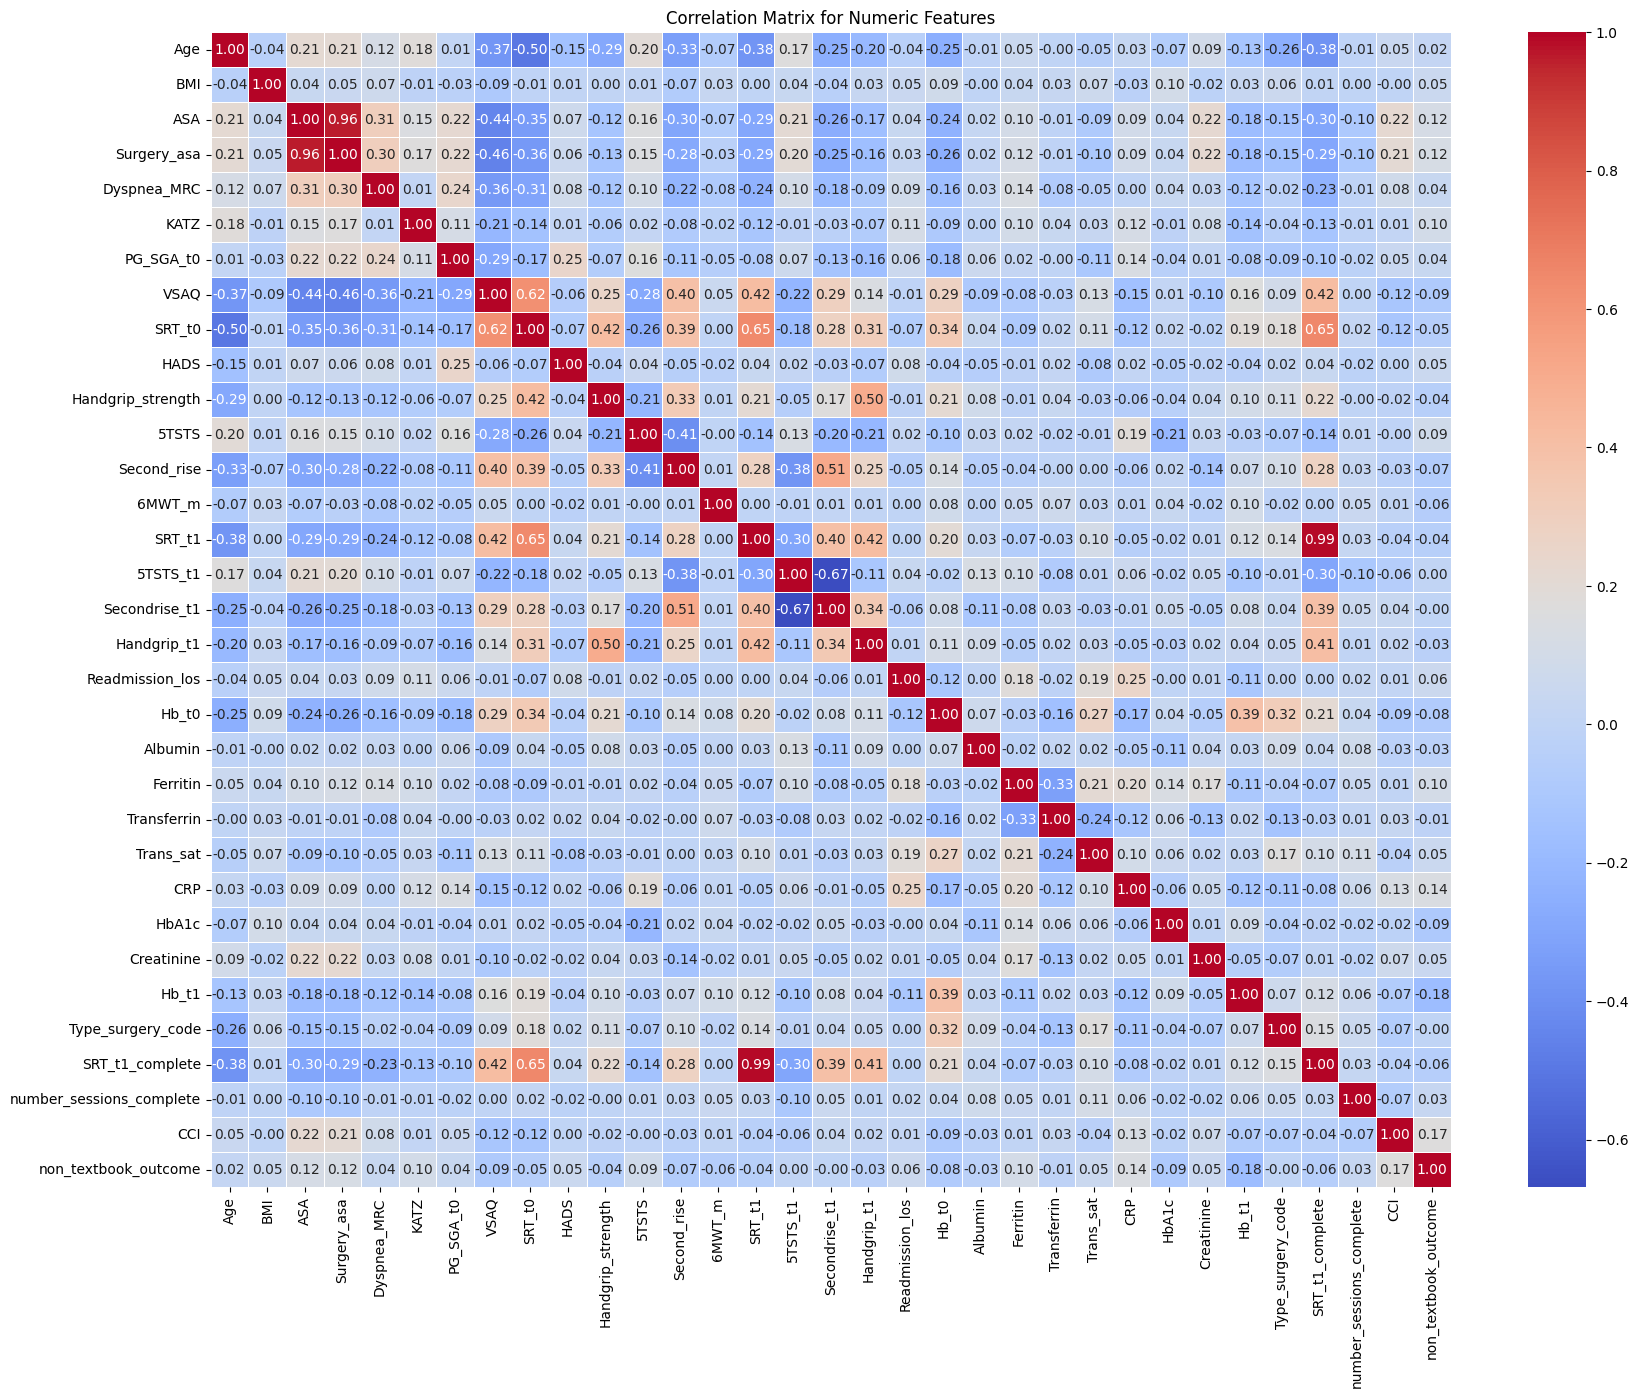

In [80]:
#create a correlation matrix for numeric features
numeric_cols = df.select_dtypes(include=['float64', 'float32','int64','int8']).columns
correlation_matrix = df[numeric_cols].corr()
# plot the correlation matrix
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Numeric Features')



In [64]:
# give the correlation of each numeric feature with the target variable
correlation_with_target = df[numeric_cols].corrwith(df['non_textbook_outcome'])
print("Correlation of numeric features with target variable:")
print(correlation_with_target.sort_values(ascending=False))


Correlation of numeric features with target variable:
non_textbook_outcome        1.000000
CCI                         0.167814
CRP                         0.141544
Surgery_asa                 0.120704
ASA                         0.118680
Ferritin                    0.101109
KATZ                        0.099344
5TSTS                       0.086473
Readmission_los             0.055880
BMI                         0.054707
HADS                        0.049716
Trans_sat                   0.049306
Creatinine                  0.048148
PG_SGA_t0                   0.037703
Dyspnea_MRC                 0.037382
number_sessions_complete    0.029643
Age                         0.016633
5TSTS_t1                    0.002958
Type_surgery_code          -0.000946
Secondrise_t1              -0.003659
Transferrin                -0.010288
Albumin                    -0.028314
Handgrip_t1                -0.032404
Handgrip_strength          -0.043514
SRT_t1                     -0.044552
SRT_t0               

In [65]:

import statsmodels.api as sm
import pandas as pd

X = df[numeric_cols]     # or df[all_features]
y = df["non_textbook_outcome"]

univariate_results = []

for col in X.columns:
    try:
        model = sm.Logit(y, sm.add_constant(X[col])).fit(disp=0)
        p = model.pvalues[1]
        or_val = model.params[1]
        univariate_results.append([col, p, or_val])
    except:
        pass

uni_df = pd.DataFrame(univariate_results, columns=["Variable", "p_value", "Odds_ratio"])
uni_df.sort_values("p_value").head(20)


,Variable,p_value,Odds_ratio
27,Hb_t1,0.000277,-0.585802
31,CCI,0.000974,0.299810
24,CRP,0.005817,0.013905
3,Surgery_asa,0.009155,0.428994
2,ASA,0.010371,0.432384
5,KATZ,0.043117,0.339542
21,Ferritin,0.046411,0.001197
7,VSAQ,0.058515,-0.090073
25,HbA1c,0.059008,-0.109860
19,Hb_t0,0.077204,-0.162345


In [66]:
import pandas as pd

def remove_perfect_separation_columns(df, verbose=True):
    """
    Detects and removes perfect-separation (constant-value) columns from a DataFrame.
    
    Perfect separation columns are those that contain:
        - Only one unique value (e.g., all 'ja', all 'nee', all 3)
        - Or only NaN (empty) values
    
    Parameters
    ----------
    df : pandas.DataFrame
        The input dataset.
        
    verbose : bool
        If True, prints diagnostic information about detected columns.
        
    Returns
    -------
    df_clean : pandas.DataFrame
        The cleaned dataset without perfect-separation columns.
        
    removed_cols : list
        List of removed column names.
    """

    # --- Detect columns with a single unique value (or all NaN) ---
    perfect_sep_cols = []
    for col in df.columns:
        unique_vals = df[col].dropna().unique()
        
        # Explanation:
        # If number of unique non-NaN values ≤ 1 → column is constant.
        if len(unique_vals) <= 1:
            perfect_sep_cols.append(col)

    if verbose:
        print("\n=== Perfect-Separation Columns Detected ===")
        if perfect_sep_cols:
            for c in perfect_sep_cols:
                print(f"  - {c}")
        else:
            print("No perfect-separation columns found.")

    # Remove these columns
    df_clean = df.drop(columns=perfect_sep_cols)

    if verbose:
        print("\n=== Summary ===")
        print(f"Removed {len(perfect_sep_cols)} column(s).")
        print(f"Remaining columns: {df_clean.shape[1]}")

    return df_clean, perfect_sep_cols



# -------------------------------------------------------------------
# Example usage on your Excel file
# -------------------------------------------------------------------

# df = pd.read_excel("Database prehabilitatie Isala - cleaned.xlsx")
df_clean, removed = remove_perfect_separation_columns(df)
# df_clean.to_excel("Database_cleaned_no_perfect_sep.xlsx", index=False)


=== Perfect-Separation Columns Detected ===
  - Type_anesthesia

=== Summary ===
Removed 1 column(s).
Remaining columns: 50


In [67]:
X = df[numeric_cols]     # or df[all_features]
y = df["non_textbook_outcome"]

In [76]:


import pandas as pd

for col in df.columns:
    try:
        cross = pd.crosstab(df[col], df['non_textbook_outcome'])
        if (cross[0] == 0).any() or (cross[1] == 0).any():
            print("Perfect or quasi-perfect separation in column:", col)
            #print(cross)
    except:
        pass



Perfect or quasi-perfect separation in column: Age
Perfect or quasi-perfect separation in column: BMI
Perfect or quasi-perfect separation in column: Drugs
Perfect or quasi-perfect separation in column: Personal_care
Perfect or quasi-perfect separation in column: KATZ
Perfect or quasi-perfect separation in column: PG_SGA_t0
Perfect or quasi-perfect separation in column: VSAQ
Perfect or quasi-perfect separation in column: SRT_t0
Perfect or quasi-perfect separation in column: HADS
Perfect or quasi-perfect separation in column: Handgrip_strength
Perfect or quasi-perfect separation in column: 5TSTS
Perfect or quasi-perfect separation in column: Second_rise
Perfect or quasi-perfect separation in column: 6MWT
Perfect or quasi-perfect separation in column: 6MWT_m
Perfect or quasi-perfect separation in column: SRT_t1
Perfect or quasi-perfect separation in column: 5TSTS_t1
Perfect or quasi-perfect separation in column: Secondrise_t1
Perfect or quasi-perfect separation in column: Handgrip_t1
Perf

In [71]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
#remove non-textbook outcome components from X to avoid data leakage
target = 'non_textbook_outcome'
X = X.drop(columns=[target]) if target in X.columns else X
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)


BMI                  0.159495
Hb_t0                0.130631
SRT_t0               0.123384
HADS                 0.121776
5TSTS                0.113345
Creatinine           0.105474
VSAQ                 0.094546
Second_rise          0.083750
Type_surgery_code    0.067600
dtype: float64

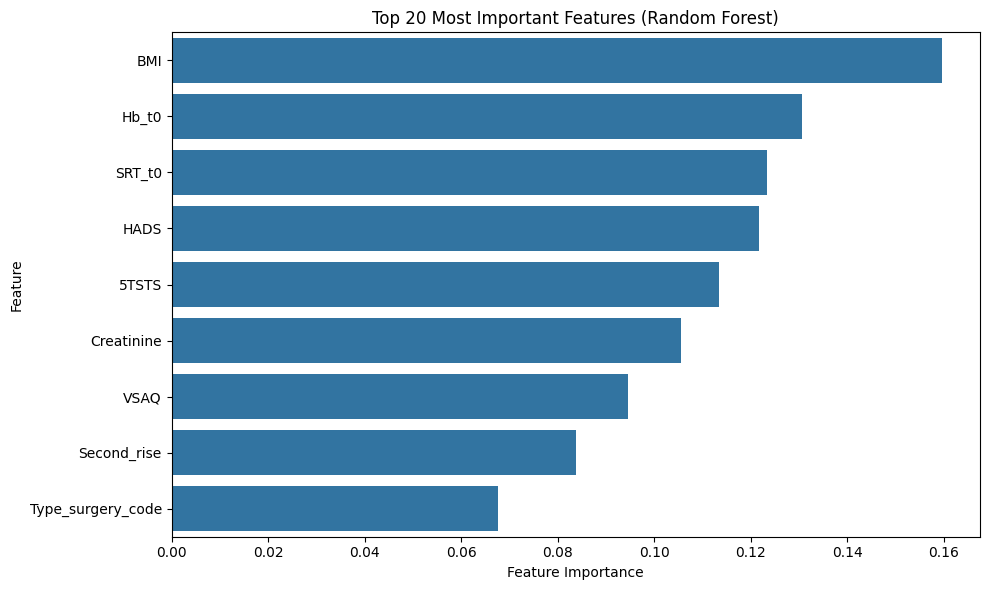

In [72]:
# create a bar plot of the top 20 most important features
plt.figure(figsize=(10, 6)) 
sns.barplot(x=importances.sort_values(ascending=False).head(20), y=importances.sort_values(ascending=False).head(20).index)
plt.title('Top 20 Most Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [73]:
# create a Random Forest model to predict non_textbook_outcome
df_rf = df.copy()  # use a copy to avoid modifying original df
df_rf = df_rf.dropna() # drop rows where target is NaN
X = df_rf[numeric_cols]     # or df[all_features]
y = df_rf["non_textbook_outcome"]
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
# use only the top 10 most important features for the model 
X = X[importances.sort_values(ascending=False).head(10).index]
print("Features used in the model:")

#remove Age from the model because it is not modifiable and has a high importance
# remove NAN values in X

X = X.drop(columns=['Age'], errors='ignore') if 'Age' in X.columns else X
X = X.dropna()
print(X.columns.tolist())

#divide data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)   
rf.fit(X, y)
# give the concordance index (AUC) of the model on the test set
y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Random Forest AUC: {auc:.3f}")
# give the confusion matrix of the model on the test set
from sklearn.metrics import confusion_matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
# give the accuracy, sensitivity, specificity of the model on the test set
from sklearn.metrics import accuracy_score, recall_score, precision_score
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)
print(f"Accuracy: {accuracy:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
# show feature importance of the model
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
print("Feature Importances:")
print(feature_importances.sort_values(ascending=False)) 



Features used in the model:
['BMI', 'Hb_t0', 'SRT_t0', 'HADS', '5TSTS', 'Creatinine', 'VSAQ', 'Second_rise', 'Type_surgery_code']
Random Forest AUC: 1.000
Confusion Matrix:
[[40  0]
 [ 0 25]]
Accuracy: 1.000
Sensitivity: 1.000
Specificity: 1.000
Feature Importances:
BMI                  0.166323
Hb_t0                0.126739
SRT_t0               0.120065
HADS                 0.119851
Creatinine           0.113027
5TSTS                0.110519
VSAQ                 0.093073
Second_rise          0.089512
Type_surgery_code    0.060890
dtype: float64


In [74]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

X = df.drop(columns=["non_textbook_outcome"])
y = df["non_textbook_outcome"]
#impute nan values in X

X = pd.get_dummies(X, drop_first=True)
X_scaled = StandardScaler().fit_transform(X)

lasso = LogisticRegressionCV(
    cv=10,
    penalty='l1',
    solver='saga',
    max_iter=500
).fit(X_scaled, y)

coef = pd.Series(lasso.coef_[0], index=X.columns)
important = coef[coef != 0].sort_values(ascending=False)
important


Series([], dtype: float64)

## Elastic Net

In [ ]:
enet = ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=10).fit(X_sc,y)
enet_sel=pd.Series(enet.coef_, index=filtered); enet_sel[enet_sel!=0]

## Random Forest Importance

In [ ]:
rf=RandomForestClassifier(n_estimators=800).fit(X_imp,y)
imp=pd.Series(rf.feature_importances_, index=filtered).sort_values(ascending=False)
imp.head(20)

## Stability Selection

In [ ]:
n=200; freq=pd.Series(0,index=filtered)
for i in range(n):
    Xi, yi = resample(X_sc, y)
    ls=LassoCV(cv=5).fit(Xi, yi)
    freq += (ls.coef_!=0).astype(int)
freq = (freq/n).sort_values(ascending=False); freq.head(20)

## Final Variable Set

In [ ]:
final=set(lasso_sel[lasso_sel!=0].index) | set(enet_sel[enet_sel!=0].index) | set(freq[freq>0.7].index)
final